In [11]:
import sys
sys.path.insert(0, '../src')

import pandas as pd

from tfm_airquality import config
from tfm_airquality.load import load_airquality_data
from tfm_airquality.clean import clean
from tfm_airquality import eda
import matplotlib.pyplot as plt
import seaborn as sns

df, informe_huecos = clean(load_airquality_data())
print(df.shape)
Y = ['NO2(GT)']
X = ['CO(GT)', 'C6H6(GT)', 'NOx(GT)',
     'PT08.S1(CO)', 'PT08.S2(NMHC)', 'PT08.S3(NOx)', 'PT08.S4(NO2)', 'PT08.S5(O3)',
     'T', 'RH', 'AH']
variables = X + Y

(9357, 15)


# Estación 4 — Análisis descriptivo

## Pregunta 1: ¿qué variables anticipan el NO₂?

La correlación contemporánea entre un sensor y el NO₂ no mide capacidad
predictiva. Este proyecto predice a 24 y 48 horas, así que lo relevante es la
relación entre el valor actual de cada variable y el NO₂ futuro.

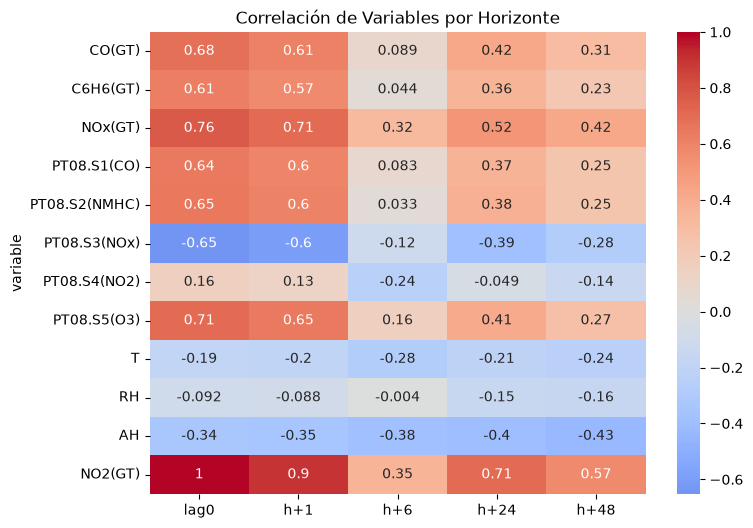

In [14]:
eda.correlacion_por_horizonte(df)

plt.figure(figsize=(8, 6))
sns.heatmap(eda.correlacion_por_horizonte(df, variables), annot=True, cmap='coolwarm', center=0)
plt.title('Correlación de Variables por Horizonte')
plt.show()

## Pregunta 2: ¿se solapan las variables entre sí?

Dos motivos para mirarlo. Primero, la multicolinealidad afecta a la estabilidad
de los modelos lineales y reparte de forma arbitraria la importancia entre
variables redundantes, lo que complica la interpretabilidad. Segundo, permite
cerrar la sospecha sobre `C6H6(GT)`.

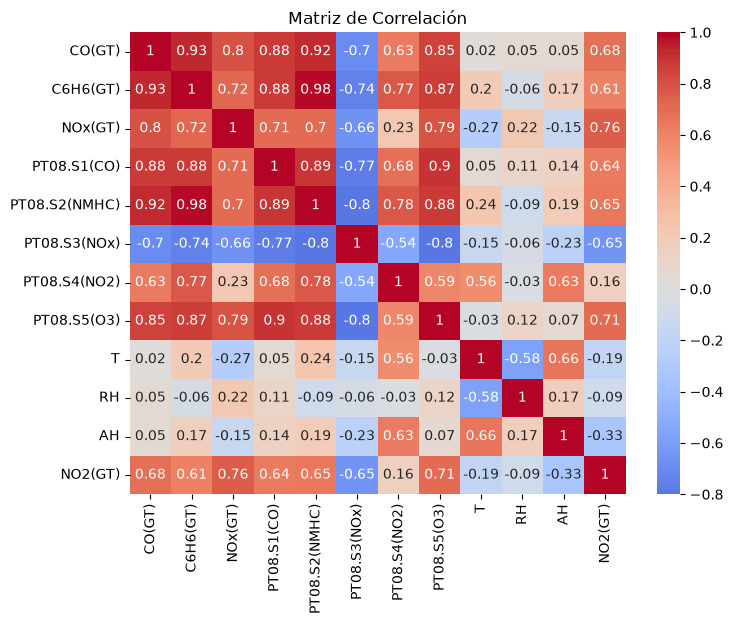

In [13]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[variables].corr().round(2), annot=True, cmap='coolwarm', center=0)
plt.title('Matriz de Correlación')
plt.show()

In [16]:
print(df['C6H6(GT)'].nunique())
print(df['PT08.S2(NMHC)'].nunique())

407
1246
